## 1. Введение

### 1.1 О продукте
**Mines & Moles** — это мобильная rogue-like игра, где игроки проходят уровни подземных шахт, 
избегая ловушек и собирая ценные предметы. Ключевая особенность: уровни генерируются случайным 
алгоритмом, что создает уникальный опыт для каждого прохождения.

### 1.2 Бизнес-контекст
- **Целевая метрика**: Выручка (Revenue) от внутриигрового магазина
- **Проблема**: С июля 2024 года наблюдается стагнация, а затем падение выручки
- **Ключевое событие**: В июне-июле было проведено обновление, включавшее:
  1. Редизайн внутриигрового магазина
  2. Корректировку алгоритма генерации уровней

### 1.3 Цель анализа
Выявить причины падения выручки и предложить рекомендации по их устранению.

## 2. Дерево метрик
Для системного подхода к анализу декомпозируем целевую метрику:

Revenue (Выручка)  
│  
├── AU (Активные пользователи)  
│ ├── New Users    
│ └── Retained Users  
│ └── Retention Rate  
│ └── Средняя доля пройденных уровней на сессию  
└── ARPAU (Доход на активного пользователя)  
├── Conversion Rate (Конверсия в покупку)  
└── AOV (Средний чек)  
├── Avg. Price per Item  
└── Avg. Items per Order  

## 3. Гипотезы

На основе дерева метрик формулируем две основные гипотезы:

### H1: Падение выручки вызвано снижением активной аудитории (AU)
- **H1.1**: Снижение притока новых пользователей
- **H1.2**: Снижение удержания существующих пользователей

### H2: Падение выручки вызвано снижением дохода с активного пользователя (ARPAU)
- **H2.1**: Снижение конверсии в покупку
- **H2.2**: Снижение среднего чека (AOV)

Далее последовательно проверим каждую гипотезу, двигаясь сверху вниз по дереву метрик.

In [ ]:
# Выгружаем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

## 4. Анализ активной аудитории (AU)

### 4.1 Динамика MAU
Проверяем базовую метрику - количество активных пользователей в месяц.

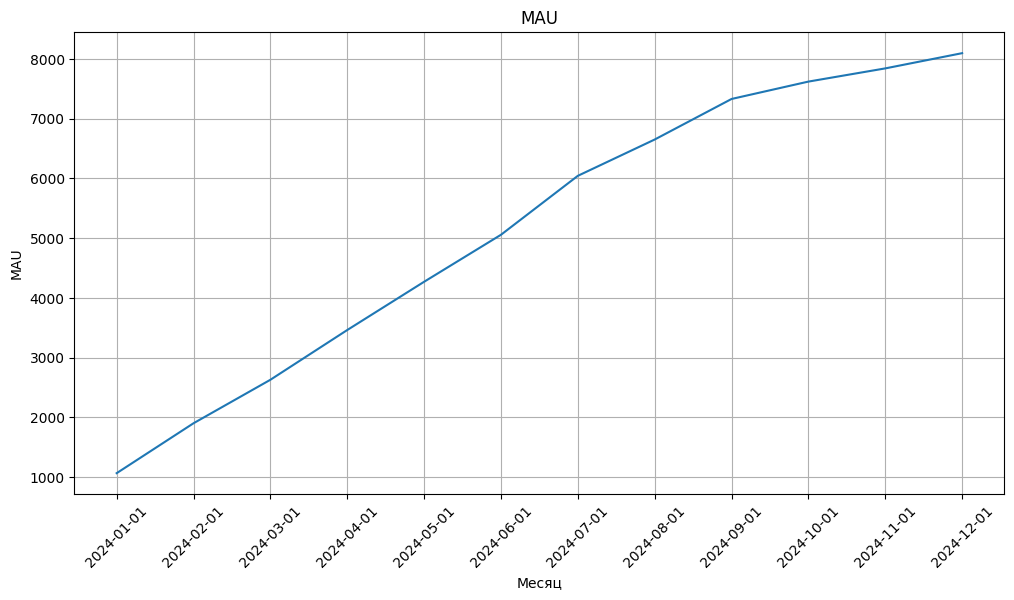

In [ ]:
# Выгружаем датафрейм
df = pd.read_csv('https://code.s3.yandex.net/datasets/PA_2_7_1_dataset.csv')

# Формируем сводную таблицу по месяцам и количеству активных пользоватлей
mau_all = df.groupby('all_activity_month')['device_id'].nunique().reset_index()

# Строим график
plt.figure(figsize=(12,6))

plt.plot(mau_all['all_activity_month'], mau_all['device_id'])

plt.title('MAU')
plt.xticks(rotation=45)
plt.xlabel('Месяц')
plt.ylabel('MAU')
plt.grid()

График показывает постоянный рост активной аудитории, продукт интересен людям. Но темпы роста замедляются к концу года.

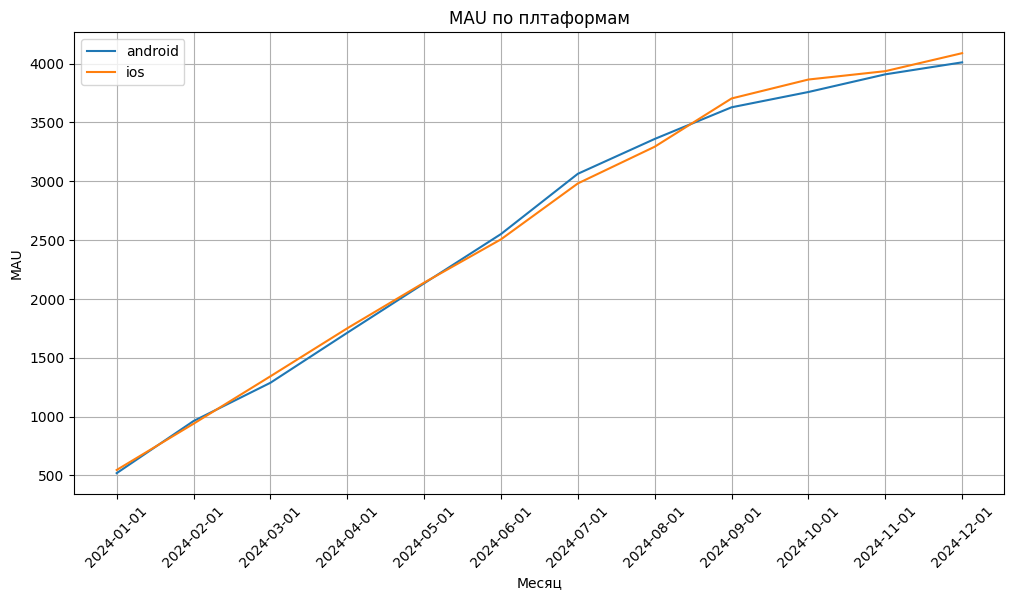

In [ ]:
# Формируем сводную таблицу по месяцам и количеству активных пользоватлей в разрезе платформ
mau_platforms = df.groupby(['all_activity_month', 'platform'])['device_id'].nunique().reset_index()

# Строим график
plt.figure(figsize=(12,6))

# Цикл для построения графика по каждой платформе
for platform in mau_platforms['platform'].unique():
    plt.plot(mau_platforms[mau_platforms['platform'] == platform]['all_activity_month'], mau_platforms[mau_platforms['platform'] == platform]['device_id'], label=platform)

plt.title('MAU по плтаформам')
plt.xticks(rotation=45)
plt.xlabel('Месяц')
plt.ylabel('MAU')
plt.legend()
plt.grid()

Обе платформы вносят одинаковый вклад в MAU. И у IOS, и у Android наблюдаются замедления в темпах роста к концу года, возможно связанные с сезонными колебаниями.

**Вывод по MAU:** MAU продолжает расти на протяжении всего года. Гипотеза H1 о падении активной аудитории не подтверждается - аудитория не падает, 
  но наблюдается замедление роста. Необходимо углубиться в структуру активной аудитории.
  
  ### 4.2 Структура новых пользователей по каналам привлечения

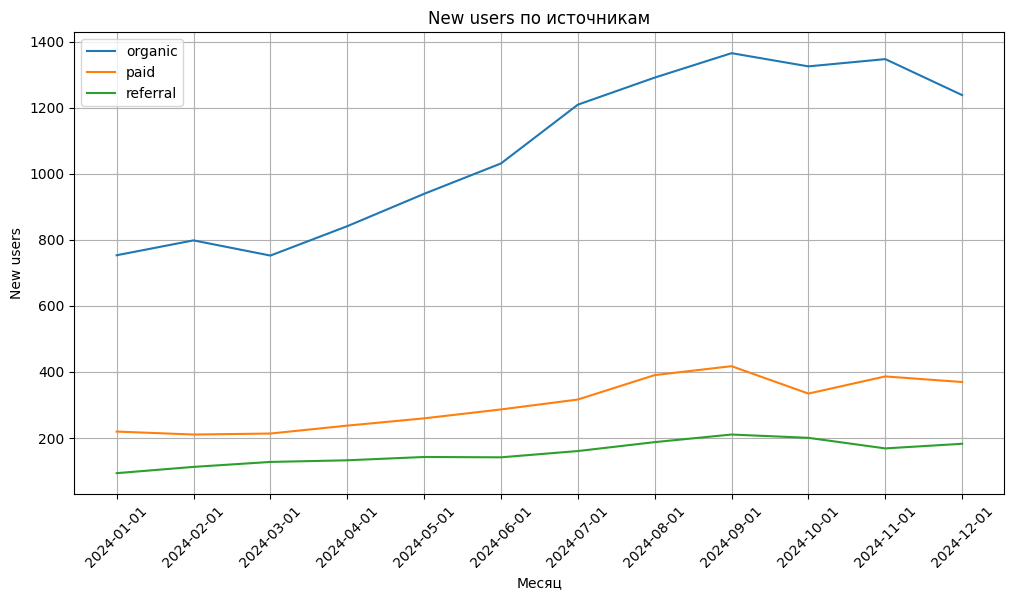

In [ ]:
# Формируем сводную таблицу по месяцам и количеству активных пользоватлей в разрезе каналов привлечения
new_users = df.groupby(['first_activity_month', 'traffic_type'])['device_id'].nunique().reset_index()

# Строим график
plt.figure(figsize=(12,6))

# Цикл для построения графика по каждому каналу
for traffic in new_users['traffic_type'].unique():
    plt.plot(new_users[new_users['traffic_type'] == traffic]['first_activity_month'],
             new_users[new_users['traffic_type'] == traffic]['device_id'],
             label=traffic
            )

plt.title('New users по источникам')
plt.xticks(rotation=45)
plt.xlabel('Месяц')
plt.ylabel('New users')
plt.legend()
plt.grid()

Органический трафик является основным источником привлечения новых пользователей. При этом платный и реферальный каналы заметно меньше по объёму, но их графики круче - значит, они растут относительно быстрее.
К концу года наблюдается небольшой спад органики.

**Вывод по новым пользователям:** гипотеза H1.1 частично подтверждается - есть проблема с притоком новых пользователей, 
  но не критическая.

  ### 4.3 Анализ удержания (Retention Rate)


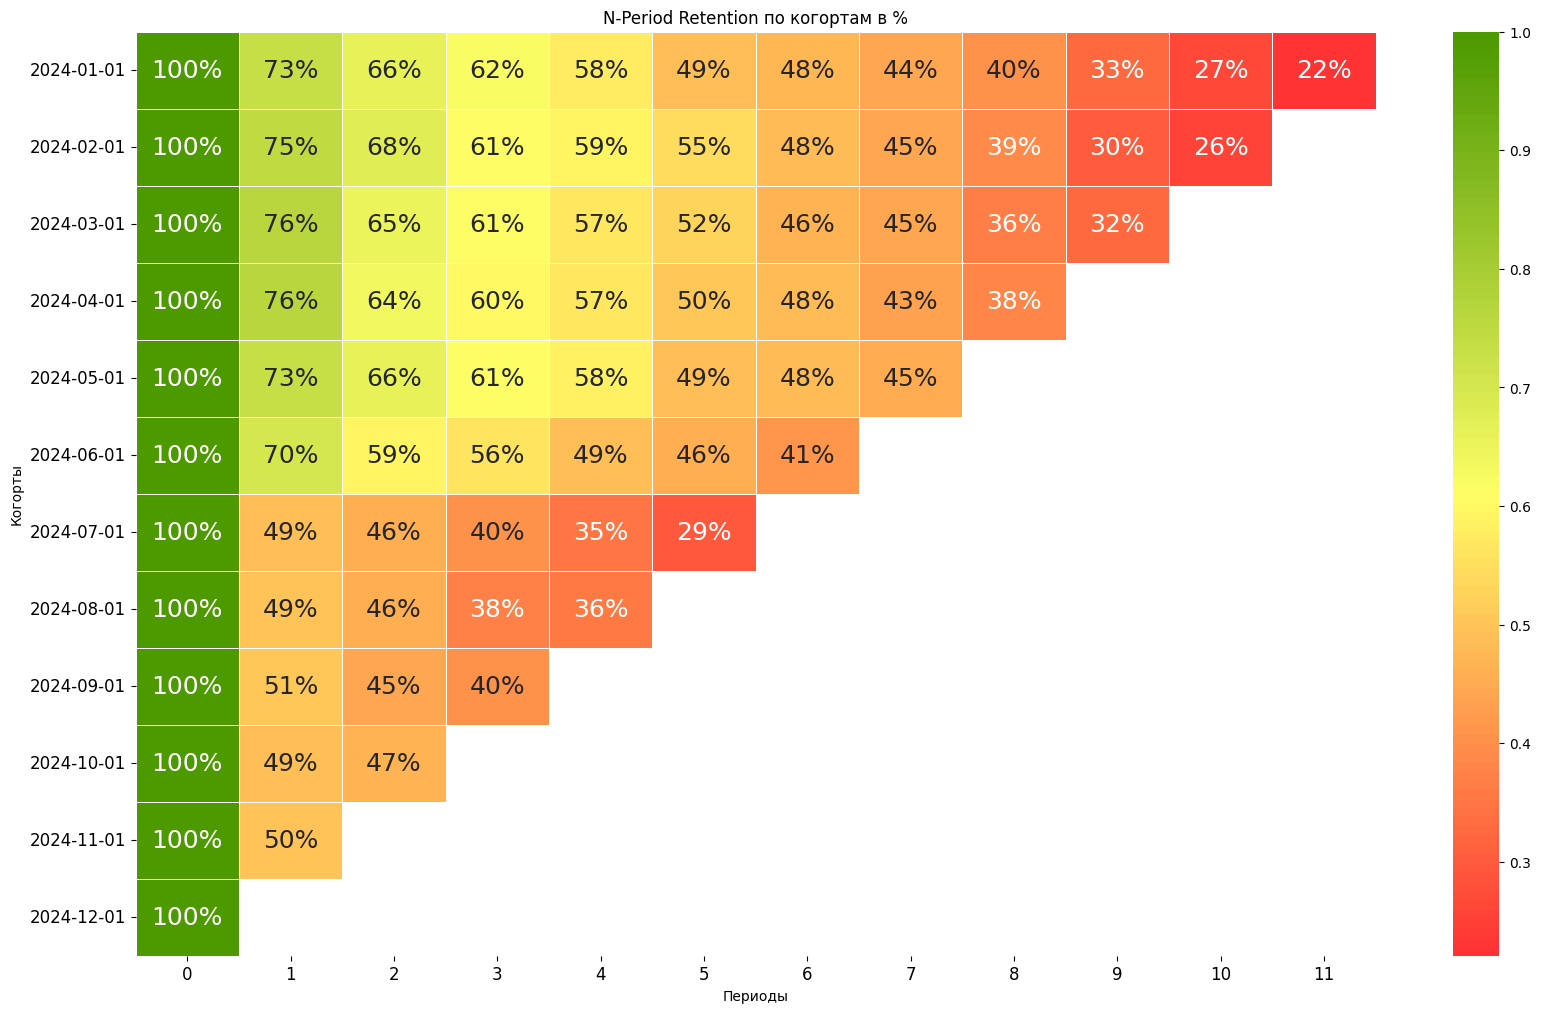

In [ ]:
# Создаем палетку для тепловой карты
cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100)

# Приводим столбцы к datetime
df['all_activity_month'] = pd.to_datetime(df['all_activity_month'])
df['first_activity_month'] = pd.to_datetime(df['first_activity_month'])

# Считаем разницу между месяцем использования и месяцем регистрации
df['n_period'] = (df['all_activity_month'].dt.to_period('M').astype('int64') - 
                 df['first_activity_month'].dt.to_period('M').astype('int64')
)

# Извлекаем дату из datetime
df['first_activity_month'] = df['first_activity_month'].dt.date

# Формируем пивот по когортам 
data_pivot = pd.pivot_table(data=df,
                            values='device_id',
                            index='first_activity_month',
                            columns='n_period',
                            aggfunc=pd.Series.nunique,
                            fill_value=0
                            
                           )

data_pivot = data_pivot.replace('', 0).astype('int')
data_pivot = data_pivot.div(data_pivot[0], axis=0)
data_pivot[data_pivot == 0] = float('nan')

# Строим график
plt.subplots(figsize=(20,12))

sns.heatmap(data_pivot,
           cmap=cmap,
           annot=True,
           fmt='.0%',
           linewidth=0.5,
           annot_kws={"size": 18})

plt.title('N-Period Retention по когортам в %')
plt.xlabel('Периоды')
plt.ylabel('Когорты')
plt.yticks(rotation=0)
plt.tick_params(labelsize=12) 
plt.show()


Удержание ожидаемо снижается со временем. С января по апрель наблюдается плавное снижение. В то время как в летний период происходит резкое падение метрики. Возможно, опыт пользователей в продукте ухудшается.

**Вывод по Retention:** гипотеза H1.2 подтверждается - удержание существенно ухудшилось. Время падения Retention совпадает с внедрением нового алгоритма генерации уровней.

### 4.4 Качество пользовательского опыта: доля пройденных уровней

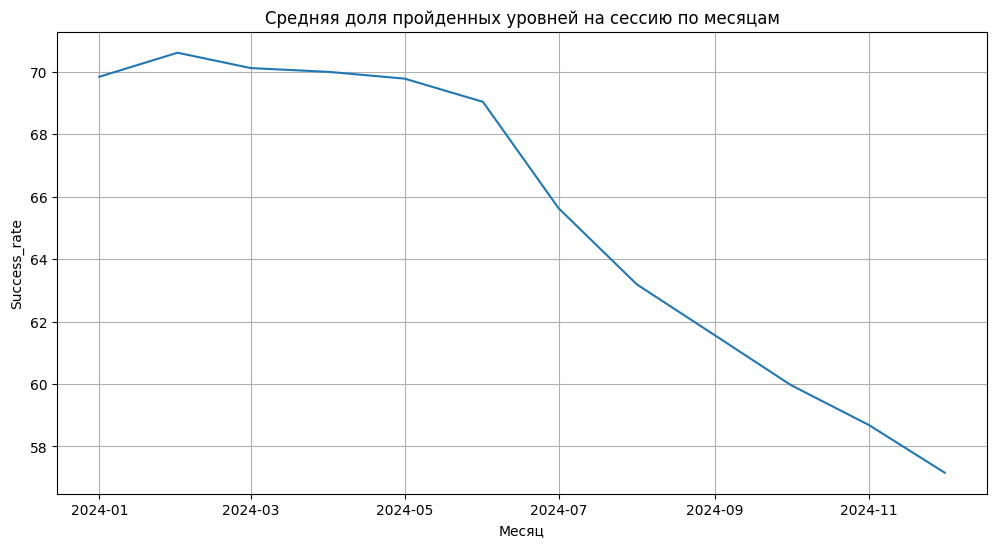

In [ ]:
# Выгружаем данные о прохождении уровней
game_sessions = pd.read_csv('https://code.s3.yandex.net/datasets/PA_2_7_1_game_sessions.csv')

# Округляем до месяца и приводим к datetime для получения динамики по месяцам
game_sessions['dt'] = pd.to_datetime(game_sessions['time_end']).dt.to_period('M').dt.to_timestamp()

# Считем долю пройденных уровней на сессию
df_grouped = (game_sessions.groupby(['dt', 'device_id', 'session_id'])
                   .agg(success=('success_fact', 'sum'),
                        total=('success_fact', 'count'))
                   .reset_index()
                   .assign(success_rate=lambda x: 100 * x['success'] / x['total'])
                   .groupby('dt')['success_rate']
                   .mean()
                   .reset_index()
             )

# Строим график
plt.figure(figsize=(12,6))

plt.plot(df_grouped['dt'], df_grouped['success_rate'])

plt.title('Средняя доля пройденных уровней на сессию по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Success_rate')
plt.grid()

Наблюдается устойчивое снижение показателя. С января по май средняя доля сессий держалась стабильно. Но начиная с летнего сезона произошло падение. Это напрямую связано с обновлением алгоритма генерации уровней.

**Промежуточный итог по H1:** Активная аудитория не падает, но замедляется рост. Основная проблема - ухудшение удержания из-за снижения качества игрового опыта.

## 5. Анализ дохода с активного пользователя (ARPAU)

### 5.1 Динамика ARPAU

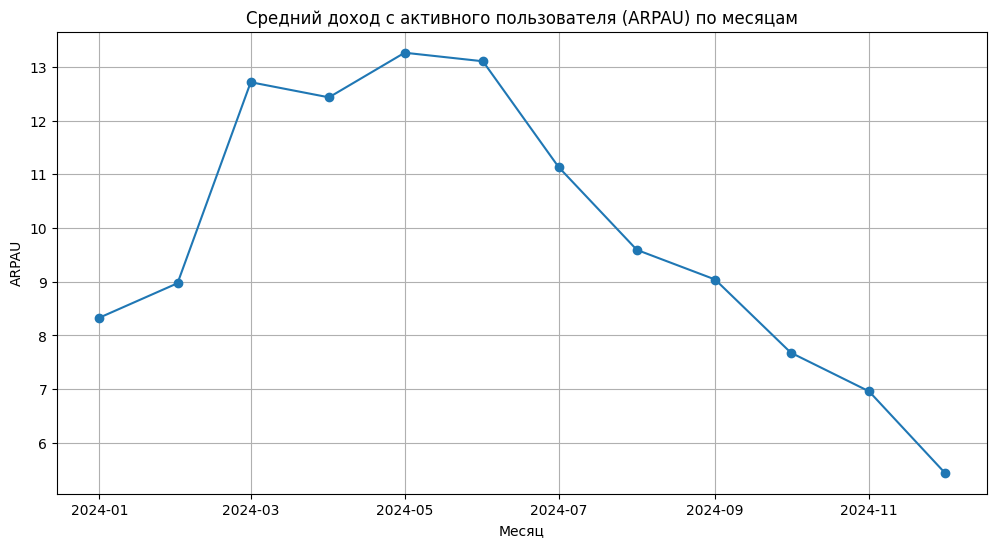

In [ ]:
# Выгружаем данныe
transactions = pd.read_csv('https://code.s3.yandex.net/datasets/PA_2_7_1_transactions.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/PA_2_7_1_events.csv')

# Приводим дату у формату месяц-год
transactions['dt'] = pd.to_datetime(transactions['time']).dt.to_period('M').dt.to_timestamp()
events['dt'] = pd.to_datetime(events['time']).dt.to_period('M').dt.to_timestamp()

# Фильтруем транзакции по успешной оплате и считаем суммы стоимостей
success_transactions = transactions[transactions['status']=='success']
transactions_sum = success_transactions.groupby('dt')['price'].sum().reset_index()

# Считаем уникальных пользователей по месяцам
users_n = events.groupby('dt')['device_id'].nunique().reset_index()

# Соединяем информацию с транзакциями и количеством юзеров
merged_df = transactions_sum.merge(users_n, on='dt')
merged_df['ARPAU'] = merged_df['price'] / merged_df['device_id']

# Строим график
plt.figure(figsize=(12,6))

plt.plot(merged_df['dt'], merged_df['ARPAU'], marker='o')

plt.title('Средний доход с активного пользователя (ARPAU) по месяцам')
plt.xlabel('Месяц')
plt.ylabel('ARPAU')
plt.grid()

С января по июнь график демонстрирует рост средней выручки. Но в июне происходит перелом и метрика падает. В это время произошел редизайн внутриигрового магазина.

**Гипотеза H2 подтверждается:** доход с пользователя существенно снизился. Время падения совпадает с редизайном внутриигрового магазина.

### 5.2 Анализ конверсионной воронки

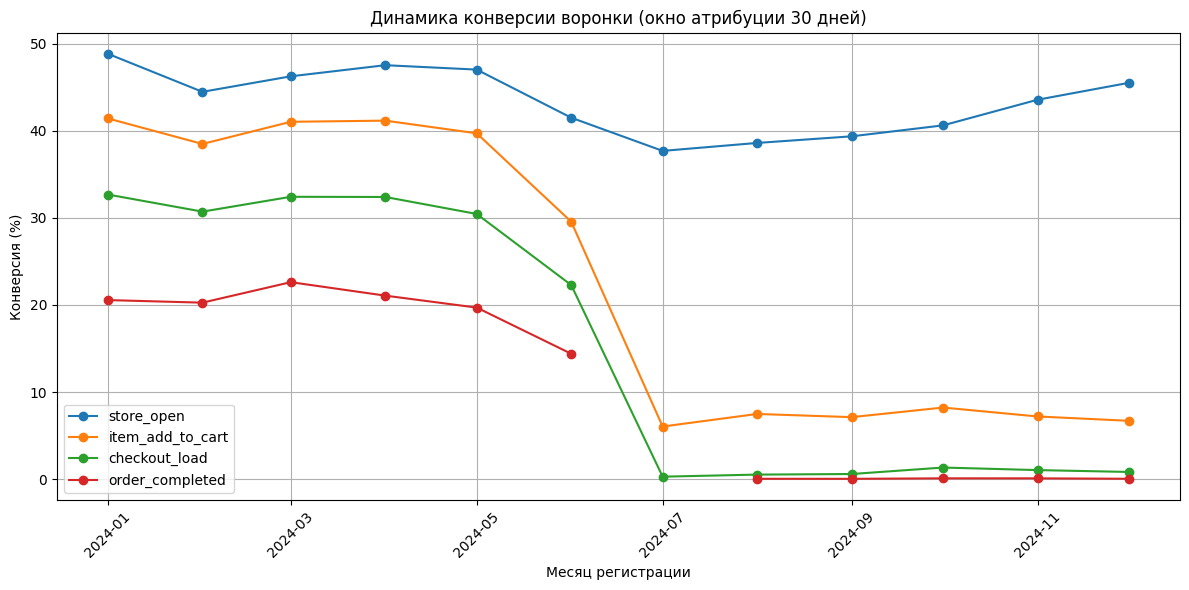

In [ ]:
# Загружаем информацию о пользователях
users = pd.read_csv('https://code.s3.yandex.net/datasets/PA_2_7_1_users.csv')

# Преобразуем дату
events['time'] = pd.to_datetime(events['time'])
users['install_time'] = pd.to_datetime(users['install_time'])

# Объединяем пользователей с их событиями
df = pd.merge(events, users[['device_id', 'install_time']], on='device_id', how='left')

# Параметры анализа
attribution_window = 30
df['diff_days'] = (df['time'] - df['install_time']).dt.days
df = df[(df['diff_days'] >= 0) & (df['diff_days'] <= attribution_window)]
df['install_month'] = df['install_time'].dt.to_period('M').dt.to_timestamp()

# Список событий воронки
event_list = ["store_open", "item_add_to_cart", "checkout_load", "order_completed"]

# Базовый уровень - количество установок по месяцам
funnel_dynamic = df.groupby('install_month')['device_id'].nunique().reset_index(name='install_devices')

# Строим график
plt.figure(figsize=(12, 6))

# Цикл для конверсии в каждое событие
for event in event_list:
    df_event = df[df['event_name'] == event].groupby('install_month')['device_id'].nunique().reset_index(name=event)
    funnel_dynamic = funnel_dynamic.merge(df_event, on='install_month', how='left')
    funnel_dynamic[event] = (funnel_dynamic[event] / funnel_dynamic['install_devices']) * 100  # Конверсия от числа установок
    plt.plot(funnel_dynamic['install_month'], funnel_dynamic[event], marker='o', label=event)
    
plt.title('Динамика конверсии воронки (окно атрибуции 30 дней)')
plt.xlabel('Месяц регистрации')
plt.ylabel('Конверсия (%)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

До июня этапы показывают стабильную конверсию. Но после июня происходит резкое снижение в ключевых этапах. В июле точка разрыва `order_completed` говорит об отсутствии внутриигровых покупок в этом месяце. 
Редизайн внутриигрового магазина, проведенный летом, привел к критическому падению конверсии на всех ключевых этапах.

**Гипотеза H2.1 подтверждается:** конверсия в покупку снизилась катастрофически.

### 5.3 Анализ среднего чека (AOV) и его компонентов

C:\Users\Asus\AppData\Local\Temp\ipykernel_19628\3594906107.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


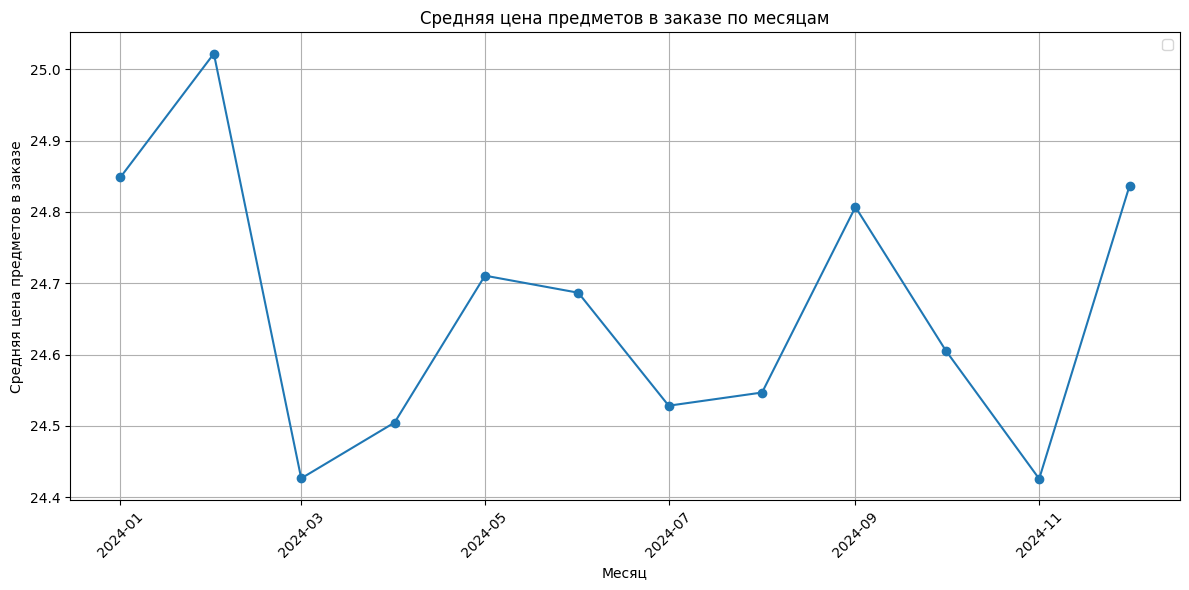

In [ ]:
# Считаем суммы заказов и количество предметов
grouped_transactions = success_transactions.groupby('dt').agg(
   price_sum=('price', 'sum'),
   item_quantity=('transaction_id', 'count')
).reset_index()

# Считаем среднюю цену предметов
grouped_transactions['avg_item_price'] = grouped_transactions['price_sum'] / grouped_transactions['item_quantity']

# Строим график
plt.figure(figsize=(12,6))

plt.plot(grouped_transactions['dt'], grouped_transactions['avg_item_price'], marker='o')

plt.title('Средняя цена предметов в заказе по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Средняя цена предметов в заказе')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Колебания средней цены незначительны (в пределах 24.4-25.0), что подтверждает отсутствие изменений в ценовой стратегии. Падение выручки вызвано исключительно снижением числа покупок.

C:\Users\Asus\AppData\Local\Temp\ipykernel_19628\3408381115.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


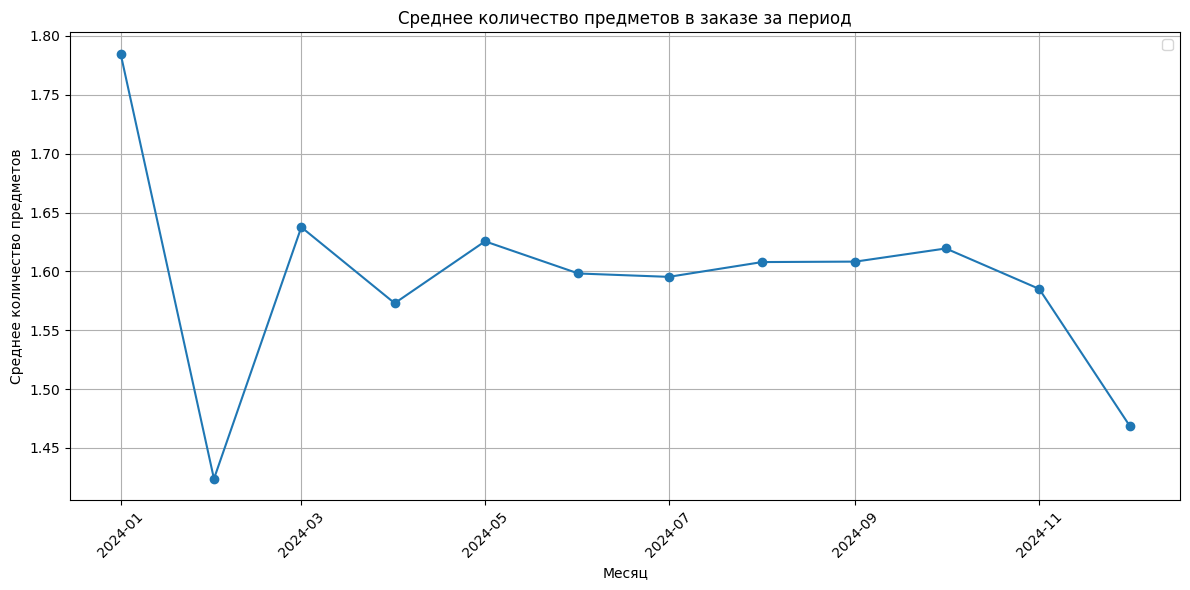

In [ ]:
# Считаем количество заказов и предметов
grouped_transactions = success_transactions.groupby('dt').agg(
   order_quantity=('transaction_id', 'nunique'),
   item_quantity=('transaction_id', 'count')
).reset_index()

# Считаем среднее число предметов
grouped_transactions['avg_item_count'] = grouped_transactions['item_quantity'] / grouped_transactions['order_quantity']

# Строим график
plt.figure(figsize=(12,6))

plt.plot(grouped_transactions['dt'], grouped_transactions['avg_item_count'], marker='o')

plt.title('Среднее количество предметов в заказе за период')
plt.xlabel('Месяц')
plt.ylabel('Среднее количество предметов')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

В феврале произошло падение, возможно связанное со сбоем работы магазина. После произошла стабилизация и большую часть года метрика колебалась незначительно. 
После летнего редизайна сохраняется стабильность по количеству предметов в заказе. Основная проблема связана с сокращением числа самих заказов.


C:\Users\Asus\AppData\Local\Temp\ipykernel_19628\1252053376.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


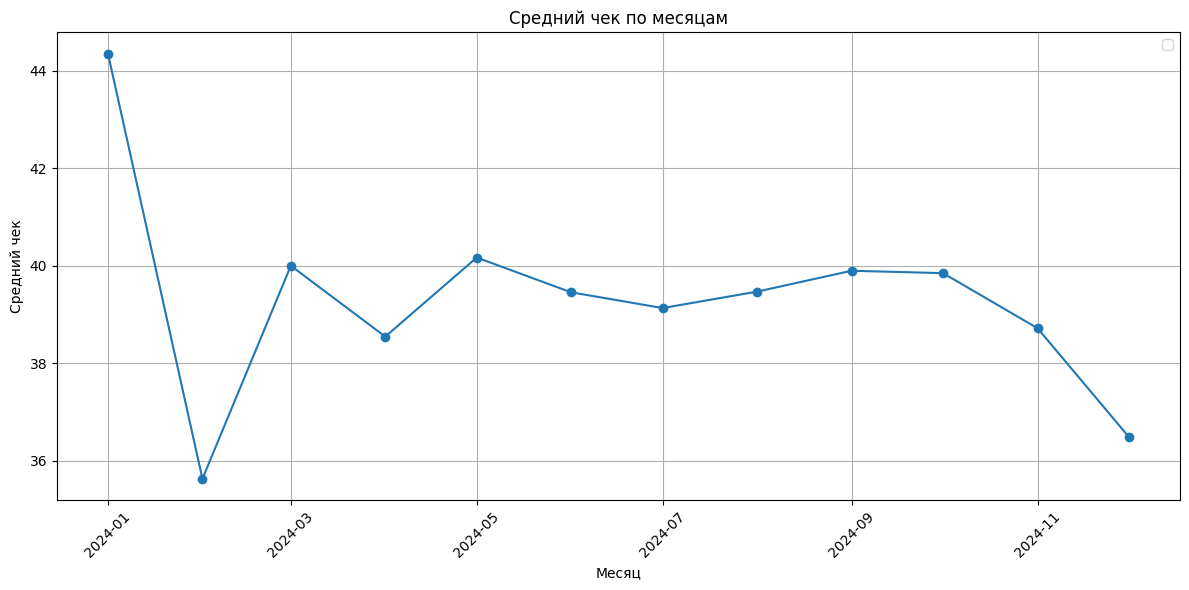

In [ ]:
# Считаем количество заказов, предметов и стоимости
grouped_transactions = success_transactions.groupby('dt').agg(
   order_quantity=('transaction_id', 'nunique'),
   item_quantity=('transaction_id', 'count'),
   price_sum=('price', 'sum')
).reset_index()

# Считаем средний чек
grouped_transactions['avg_item_count'] = grouped_transactions['item_quantity'] / grouped_transactions['order_quantity']
grouped_transactions['avg_item_price'] = grouped_transactions['price_sum'] / grouped_transactions['item_quantity']
grouped_transactions['AOV'] = grouped_transactions['avg_item_price'] * grouped_transactions['avg_item_count']

# Строим график
plt.figure(figsize=(12,6))

plt.plot(grouped_transactions['dt'], grouped_transactions['AOV'], marker='o')

plt.title('Средний чек по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Средний чек')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

График среднего чека (AOV) показывает резкое падение в феврале после январского пика, затем стабилизацию и постепенное снижение к концу года. Количество товаров в заказе повторило эту динамику. Основная проблема монетизации связана не с параметрами заказов, а с общим сокращением количества покупок после редизайна магазина.

**Гипотеза H2.2 не подтверждается:** проблемы не в структуре чека, а в количестве заказов.

### 5.4 От чека к покупателям: почему падает конверсия?
Если чек не изменился, но ARPAU упал, значит, снизилось количество платящих пользователей (конверсия).

Но почему пользователи перестали покупать? Возможные причины:
1. Магазин стал неудобным — редизайн мог сломать пользовательский путь
2. Пользователи перестали доходить до момента, когда покупка становится актуальной

Второй пункт особенно важен, потому что маркетинговые исследования показали: ключевой порог монетизации в Mines & Moles — это прохождение 10 уровней. Именно после этого пользователи начинают активно покупать предметы для прохождения более сложных шахт.

Как изменилась доля пользователей, достигающих этого порога?

C:\Users\Asus\AppData\Local\Temp\ipykernel_19628\1703478712.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


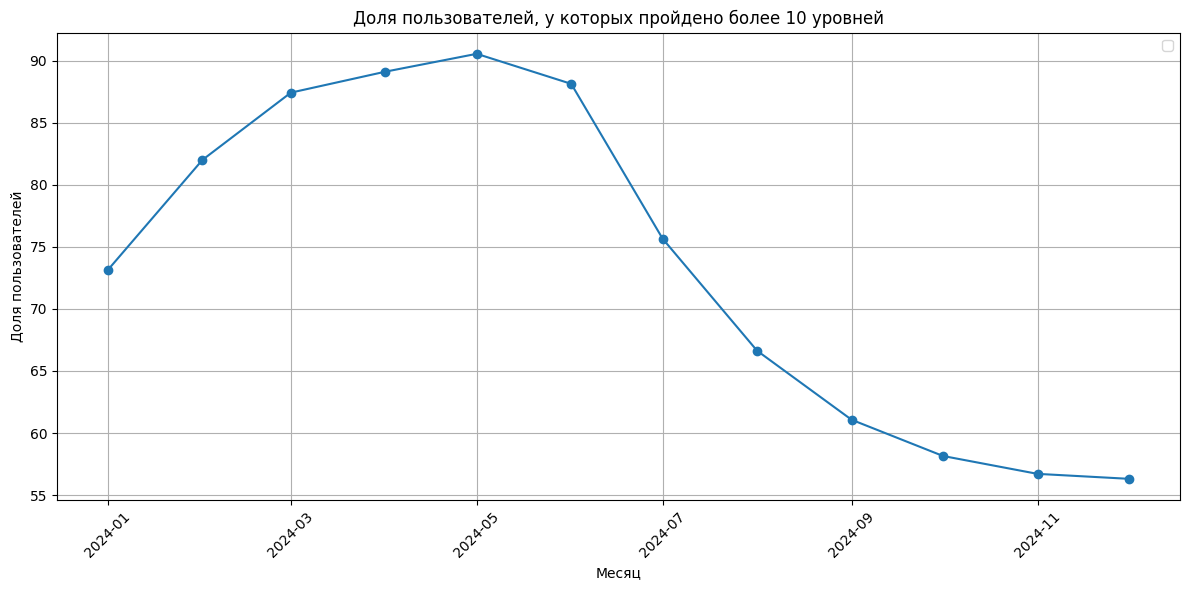

In [ ]:
# Преобразуем дату установки к нужному формату
users['dt'] = pd.to_datetime(users['install_time']).dt.to_period('M').dt.to_timestamp()

# Фильтруем по пройденному уровню
df_levels = game_sessions[(game_sessions['level_id'] == 11) & (game_sessions['success_fact'] == 1)]

# Считаем пользователей по месяцам
df_levels_grouped = df_levels.groupby('dt')['device_id'].nunique().reset_index()

# Считаем накоаление пользователей
df_levels_grouped['cumsum_users_level_success'] = df_levels_grouped['device_id'].cumsum()


df_users_grouped = users.groupby('dt')['device_id'].nunique().reset_index()
df_users_grouped['cumsum_users_all'] = df_users_grouped['device_id'].cumsum()

# Объединяем сессии и пользователей
table_final = pd.merge(df_levels_grouped, df_users_grouped, on='dt', how='inner')

# Считаем долю пользователей с 10 и более уровнем
table_final['levels_finish_rate'] = round(100 * (table_final['cumsum_users_level_success'] / table_final['cumsum_users_all']), 2)

# Строим график
plt.figure(figsize=(12,6))

plt.plot(table_final['dt'], table_final['levels_finish_rate'], marker='o')

plt.title('Доля пользователей, у которых пройдено более 10 уровней')
plt.xlabel('Месяц')
plt.ylabel('Доля пользователей')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

После летнего обновления алгоритмов для генерации уровней наблюдается резкое падение доли игроков, проходящих более 10 уровней. Особенно критичным стал июль, когда показатель упал сразу на 15 пунктов, что совпадает с внедрением изменений. Это свидетельствует о серьезных проблемах с балансом сложности уровней в обновленной версии игры.

## 6. Итоговые выводы и рекомендации
Летнее обновление вызвало кризис в продукте. Критически пострадали: Retention rate, средняя доля пройденных уровней на сессию, доля пользователей, у которых пройдено более 10 уровней, воронка конверсии и ARPAU. Обновление включило в себя редизайн внутриигрового магазина и корректировку алгоритма, который генерирует уровни. Редизайн магазина разрушил воронку конверсии — количество успешных покупок уменьшилось, что повлекло за собой снижение ARPAU. Новый алгоритм генерации уровней повысил их сложность, из-за чего пользователи начали залипать на первых уровнях и бросать прохождение, уменьшая удержание (RR). 
Рекомендуется откатить изменения и провести A/B тестирование.